## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better chart appearance
plt.style.use('ggplot')

## Loading Dataset

In [2]:
# Load dataset

df = pd.read_csv('failure_data1.csv')

# View first 5 rows
print(df.head())

   BANKNO  BIDCITY              BIDNAME BIDSTATE BRDATE BSTATUS     CERT  \
0     NaN        0                    0        0    NaN     NaN      NaN   
1     NaN        0                    0        0    NaN     NaN      NaN   
2     NaN        0                    0        0    NaN     NaN      NaN   
3     NaN  LINCOLN  UNION BANK&TRUST CO       NE    NaN       I  13797.0   
4     NaN        0                    0        0    NaN       I  18388.0   

  CHCLASS CHCLASS1         CITY  ... PTRDATE QBFASSET   QBFDEP    RESDATE  \
0      NM       NM  EAST PEORIA  ...       0    374.0    238.0        NaN   
1      NM       NM    GRANTWOOD  ...       0   2305.0    590.0        NaN   
2      NM       NM     CUMMINGS  ...       0      NaN     30.0        NaN   
3      NM       NM       TAYLOR  ...       0  14542.0  13360.0  5/31/1985   
4      NM       NM    FAIRFIELD  ...       0   6795.0   6034.0  5/31/1985   

   RESTYPE RESTYPE1  SAVR  TERMI UNINSDEP  URL  
0  FAILURE       PO  FDIC    Na

## Inspecting Relevant Columns

In [3]:
# Check column names
print(df.columns)

# Check dataset info
print(df.info())

Index(['BANKNO', 'BIDCITY', 'BIDNAME', 'BIDSTATE', 'BRDATE', 'BSTATUS', 'CERT',
       'CHCLASS', 'CHCLASS1', 'CITY', 'CITYST', 'CLOSCD', 'COMMENTS', 'COST',
       'COSTMOSTRECENTASOF', 'FAILDATE', 'FAILYR', 'FIN', 'FSL_PROG', 'FUND',
       'ID', 'NAME', 'PSTALP', 'PTRDATE', 'QBFASSET', 'QBFDEP', 'RESDATE',
       'RESTYPE', 'RESTYPE1', 'SAVR', 'TERMI', 'UNINSDEP', 'URL'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4114 entries, 0 to 4113
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BANKNO              747 non-null    float64
 1   BIDCITY             4114 non-null   object 
 2   BIDNAME             4114 non-null   object 
 3   BIDSTATE            3873 non-null   object 
 4   BRDATE              930 non-null    object 
 5   BSTATUS             2903 non-null   object 
 6   CERT                3626 non-null   float64
 7   CHCLASS             4114 non-null   object 
 8 

## Selecting Relevant Columns

In [4]:
# Select relevant columns

financial_df = df[['COST', 'FAILDATE', 'FAILYR', 'RESTYPE1', 'PSTALP']].copy()

# Display sample
financial_df.head()

,COST,FAILDATE,FAILYR,RESTYPE1,PSTALP
0,NaN,5/28/1934,1934,PO,IL
1,NaN,1/3/1935,1935,PO,NJ
2,NaN,12/21/1936,1936,P&A,ND
3,1653.0,5/31/1985,1985,PA,NE
4,1656.0,5/31/1985,1985,PO,NE


## Data Cleaning
#### 1. Cleaning COST Column

In [5]:
# Convert COST to numeric
financial_df['COST'] = pd.to_numeric(financial_df['COST'], errors='coerce')

In [6]:
# Remove rows where COST is missing
financial_df = financial_df.dropna(subset=['COST'])

In [7]:
# Keep only positive costs
financial_df = financial_df[financial_df['COST'] > 0]

#### 2. Cleaning FAILDATE Column

In [8]:
# Convert FAILDATE to datetime
financial_df['FAILDATE'] = pd.to_datetime(financial_df['FAILDATE'], errors='coerce')

#### 3. Creating Decade Column

In [9]:
# Convert FAILYR to numeric
financial_df['FAILYR'] = pd.to_numeric(financial_df['FAILYR'], errors='coerce')

In [10]:
# Create decade column
financial_df['Decade'] = (financial_df['FAILYR'] // 10) * 10

In [11]:
# Convert to integer
financial_df['Decade'] = financial_df['Decade'].astype('Int64')

In [12]:
financial_df.head()

,COST,FAILDATE,FAILYR,RESTYPE1,PSTALP,Decade
3,1653.0,1985-05-31,1985,PA,NE,1980
4,1656.0,1985-05-31,1985,PO,NE,1980
5,1118.0,1985-05-31,1985,PA,NE,1980
6,165.0,1985-05-31,1985,PO,NE,1980
7,327146.0,1985-05-31,1985,A/A,CA,1980


# Question 1 : How expensive are failures?

In [13]:
# Summary statistics
financial_df['COST'].describe()

count    3.374000e+03
mean     8.720320e+04
std      5.341821e+05
min      1.000000e+00
25%      3.588250e+03
50%      1.212350e+04
75%      4.449275e+04
max      1.895962e+07
Name: COST, dtype: float64

**Insights**
* The mean is much higher than the median.
* This indicates strong right-skewness.
* A small number of bank failures account for very large losses.

# Question 2: Are costs evenly distributed or skewed?
### 1. Histogram of COST

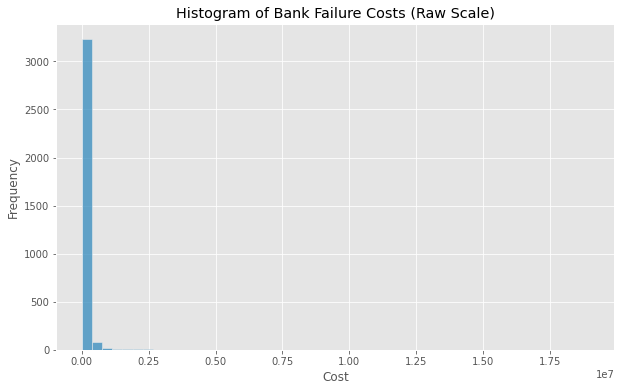

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(financial_df['COST'], bins=50)

plt.title('Histogram of Bank Failure Costs (Raw Scale)')
plt.xlabel('Cost')
plt.ylabel('Frequency')

plt.show()

**Insights**
* Most failures cluster at lower costs.
* A few extremely expensive failures stretch the distribution.
* This creates a heavily right-skewed distribution.

### 2. Log-Scaled Histogram of Cost
Reveals Underlying Structure

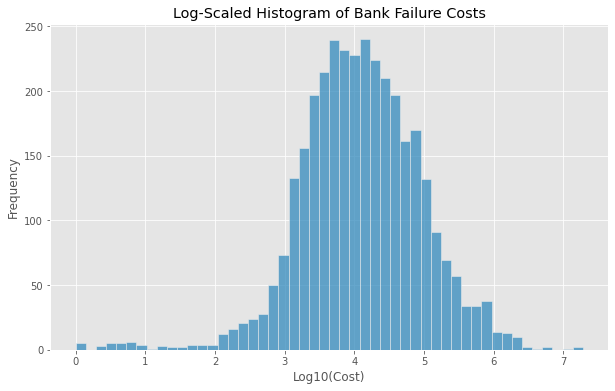

In [15]:
# Create log transformed cost
financial_df['Log_COST'] = np.log10(financial_df['COST'])

plt.figure(figsize=(10,6))

sns.histplot(financial_df['Log_COST'], bins=50)

plt.title('Log-Scaled Histogram of Bank Failure Costs')
plt.xlabel('Log10(Cost)')
plt.ylabel('Frequency')

plt.show()

**Insights**
* Log transformation reduces the impact of extreme outliers.
* The underlying distribution becomes more visible.
* Bank failure costs appear more structured after scaling

# Question 3: How does cost vary by decade, state, or resolution type?

### 1. Boxplot of Cost by Decade
Shows why the 1980s have the widest spread

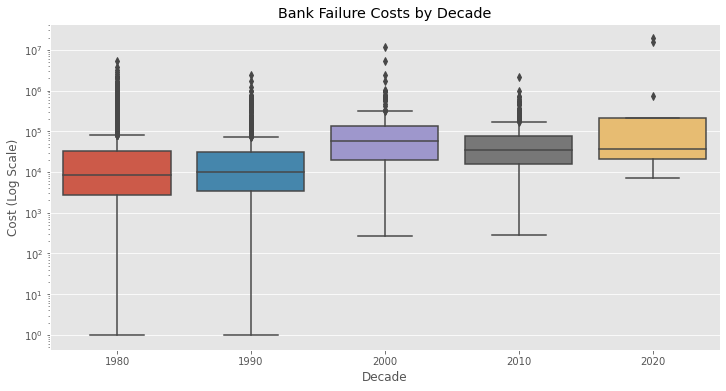

In [16]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Decade',
    y='COST',
    data=financial_df
)

plt.yscale('log')

plt.title('Bank Failure Costs by Decade')
plt.xlabel('Decade')
plt.ylabel('Cost (Log Scale)')

plt.show()

**Insights**
* The 1980s show the largest spread in costs.
* Several extremely high-cost outliers occurred during this period.
* This reflects instability associated with the Savings and Loan Crisis.

**Historical Context**

The 1980s banking crisis in the United States, especially the Savings and Loan Crisis, caused hundreds of institutional failures. Deregulation, risky lending, and interest rate volatility contributed to unusually large financial losses.

### 2. Average Cost by Resolution Type

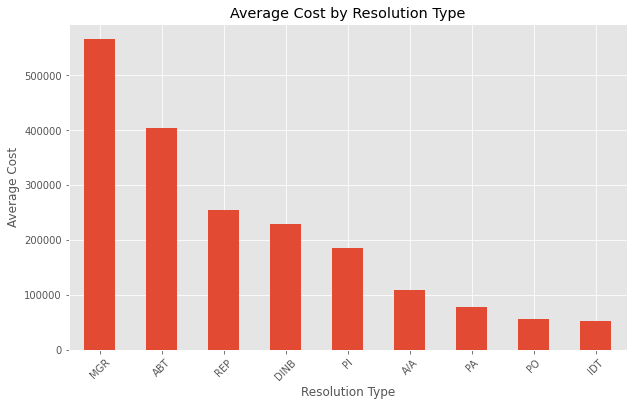

In [17]:
# Average cost by resolution type
resolution_cost = (
    financial_df
    .groupby('RESTYPE1')['COST']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

resolution_cost.plot(kind='bar')

plt.title('Average Cost by Resolution Type')
plt.xlabel('Resolution Type')
plt.ylabel('Average Cost')

plt.xticks(rotation=45)
plt.show()

**Insight**
* Assistance-related resolutions have the highest average costs.
* These failures usually involve large or complex institutions.
* More resources are required to stabilize or absorb these banks.

**Important Resolution Types**
* PA → Purchase & Assumption
* PO → Payoff
* Assistance → Direct financial assistance to troubled institutions

### 3. Top 10 States by Average Cost

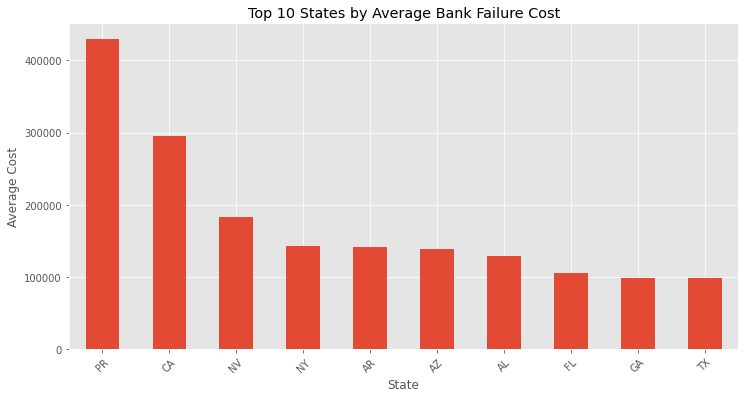

In [18]:
# Average cost by state
state_cost = (
    financial_df
    .groupby('PSTALP')['COST']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

state_cost.plot(kind='bar')

plt.title('Top 10 States by Average Bank Failure Cost')
plt.xlabel('State')
plt.ylabel('Average Cost')

plt.xticks(rotation=45)
plt.show()

**Insights**
* A few states dominate average failure costs.
* Large regional banking markets tend to generate higher losses.
* States heavily affected during financial crises show elevated averages.

# Final Key Insights
### Main Findings
#### 1. Costs are extremely skewed
Most bank failures involve relatively small losses.
A small number of failures account for massive financial impact.
#### 2. The 1980s show the widest spread and highest outliers
The Savings and Loan Crisis created unusually large variability.
Deregulation and risky lending practices increased systemic risk.
#### 3. Assistance deals are the most expensive
These cases often involve large or systemically important institutions.
Government intervention increases total resolution cost.
#### 4. A few failures dominate total losses
Financial risk is highly concentrated.
Large institutional failures can destabilize the broader banking system.

# Strong Historical Incidents
### 1. Savings and Loan Crisis (1980s)
* Deregulation allowed risky investments.
* Interest rate volatility weakened institutions.
* Hundreds of savings institutions collapsed.

### 2. 2008 Financial Crisis
* Mortgage-backed securities and subprime lending increased systemic risk.
* Large institutions failed or required intervention.
* FDIC resolution costs increased significantly.

### 3. COVID-19 Economic Shock
* Economic uncertainty increased pressure on financial institutions.
* Emergency liquidity measures helped stabilize the banking system.

# DASHBOARD

In [20]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -----------------------------------
# PREPARE DATA
# -----------------------------------

# Log transformation
financial_df['Log_COST'] = np.log10(financial_df['COST'])

# Average cost by resolution type
resolution_cost = (
    financial_df
    .groupby('RESTYPE1')['COST']
    .mean()
    .reset_index()
    .sort_values(by='COST', ascending=False)
)

# Top 10 states by average cost
state_cost = (
    financial_df
    .groupby('PSTALP')['COST']
    .mean()
    .reset_index()
    .sort_values(by='COST', ascending=False)
    .head(10)
)

# -----------------------------------
# CREATE DASHBOARD LAYOUT
# -----------------------------------

fig = make_subplots(
    rows=3,
    cols=2,

    specs=[
        [{"type": "histogram"}, {"type": "histogram"}],
        [{"type": "box", "colspan": 2}, None],
        [{"type": "bar"}, {"type": "bar"}]
    ],

    subplot_titles=(
        'Histogram of Cost (Raw Scale)',
        'Log-Scaled Histogram of Cost',
        'Boxplot of Cost by Decade',
        'Average Cost by Resolution Type',
        'Top 10 States by Average Cost'
    ),

    vertical_spacing=0.12
)

# -----------------------------------
# 1. RAW HISTOGRAM
# -----------------------------------

fig.add_trace(
    go.Histogram(
        x=financial_df['COST'],
        nbinsx=50,
        name='Raw Cost'
    ),
    row=1,
    col=1
)

# -----------------------------------
# 2. LOG HISTOGRAM
# -----------------------------------

fig.add_trace(
    go.Histogram(
        x=financial_df['Log_COST'],
        nbinsx=50,
        name='Log Cost'
    ),
    row=1,
    col=2
)

# -----------------------------------
# 3. BOXPLOT BY DECADE
# -----------------------------------

fig.add_trace(
    go.Box(
        x=financial_df['Decade'],
        y=financial_df['COST'],
        name='Cost by Decade'
    ),
    row=2,
    col=1
)

# -----------------------------------
# 4. RESOLUTION TYPE BAR CHART
# -----------------------------------

fig.add_trace(
    go.Bar(
        x=resolution_cost['RESTYPE1'],
        y=resolution_cost['COST'],
        name='Resolution Type'
    ),
    row=3,
    col=1
)

# -----------------------------------
# 5. TOP STATES BAR CHART
# -----------------------------------

fig.add_trace(
    go.Bar(
        x=state_cost['PSTALP'],
        y=state_cost['COST'],
        name='States'
    ),
    row=3,
    col=2
)

# -----------------------------------
# UPDATE LAYOUT
# -----------------------------------

fig.update_layout(

    title='Financial Impact of U.S. Bank Failures',

    # Dashboard size
    height=700,
    width=950,

    template='plotly_dark',

    showlegend=False,

    title_x=0.5,

    margin=dict(
        l=40,
        r=40,
        t=80,
        b=40
    )
)

# Log scale for boxplot
fig.update_yaxes(type='log', row=2, col=1)

# Improve subplot title appearance
fig.update_annotations(font_size=11)

# Show dashboard
fig.show()
